In [ ]:
import numpy as np
import networkx as nx

def create_graph(image, masks, adj):
    # Get average color and position for each segment
    locs = []
    colors = []
    for i in range(masks.shape[0]):
        locs.append(np.average(np.argwhere(masks[i]), axis=0))
        colors.append(np.average(image[masks[i].astype(bool)], axis=0))

    # Create graph
    G = nx.Graph()

    # Check probability of edge for each node combination
    for n in range(masks.shape[0]):
        for m in range(n + 1, masks.shape[0]):
            color_dif = (765 - np.linalg.norm(colors[n] - colors[m]))
            loc_dif = np.linalg.norm(locs[n] - locs[m])

            if np.random.rand() < adj * (color_dif / loc_dif):
                G.add_edge(n, m)
    
    return G


In [43]:
import cv2

file = "49.S.W.F"

image = cv2.imread(f"Synthetic faces/{file}.png")
masks = np.load(f"synthetic/{file}_masks.npy")

G = create_graph(image, masks, 0.5)

3


1


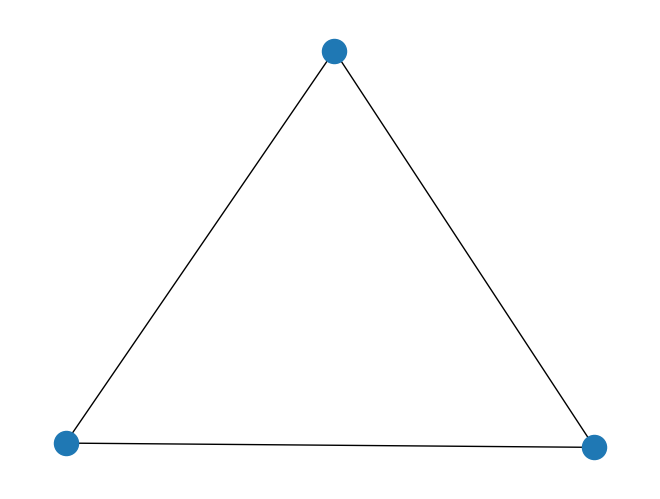

In [41]:
import matplotlib.pyplot as plt

print(nx.number_connected_components(G))

nx.draw(G)
plt.show()